#<h1><center>Lab 2 - A2</center></h1>

# Simulated Annealing (SA)

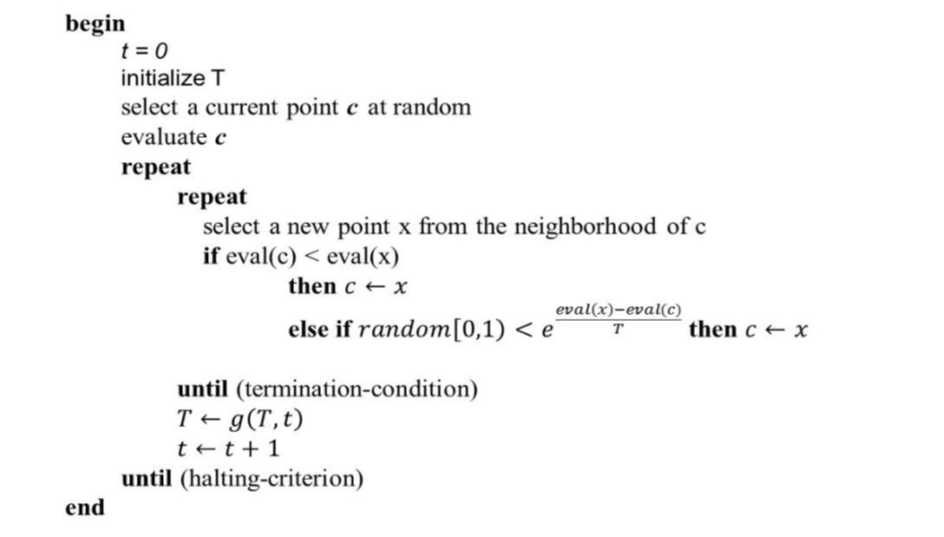


*	Schema de răcire dată de funcţia g poate fi:
 *	T(k+1)= alpha * T(k), cu alpha o valoare subunitară dar apropiată de 1 (de exemplu, alpha=0.99)  
 *	T(k+1)=T(k)/log(k+1)
 *	T(k+1)=T(k)/k  
unde T(k) este temperatura la iteraţia k.
* Valoarea iniţială a temperaturii trebuie să fie suficient de mare ex. T=10000.
*	Criteriul de oprire poate fi:
 *	Când valoarea temperaturii ajunge la  o valoare minimă prestabilită
 *	Numărul de iterații parcurse ajunge la un maxim


## Imports

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

##	Lucru în timpul laboratorului

1.	Completarea de cod în fișierul Jupyter Notebook (A2.ipynb) unde este notat cu TODO:
 1.	Completarea de cod pentru SA în cazul rezolvării problemei rucsacului (20p)
 1.	Completarea tabelului de date (10p)
 1.	Completarea de cod pentru formarea unei soluții TSP (10p)
 1. Completarea de cod pentru calcul eval/fitness soluție (10p)
 1.	Completarea de cod pentru formarea unei vecinătăți cu 2-swap (5p)
 1.	Completarea de cod pentr SA în cazul rezolvării TSP (10p)
 1.	Completarea tabelului de date (10p)

**Total Punctaj A2-Lab = 75p**

**Deadline Lab 2**

### Funcții problema rucsacului

#### Încărcare de date

In [34]:
# definire încărcare date
def load_data_rucsac(file_name: str) -> "tuple[list[tuple[int, int]], int]":
  """
  Citeste datele din fisierul file_name
  """
  weights_and_values = []
  with open(file_name) as f:
    nr_obj = int(f.readline())
    for i in range(nr_obj):
      line = f.readline()
      line = line.split(" ")
      line = [x for x in line if x != ""]
      weights_and_values.append(tuple(int(x) for x in line[1:]))
    max_capacity = int(f.readline())
  return weights_and_values, max_capacity
#load_data_rucsac("/content/rucsac-200.txt") # rucsac-20.txt and rucsac-200.txt

#### Formarea unei soluții, vecinătate și fitness

In [35]:
# definire funcții de fitness/evaluare și generare

def is_valid_rucsac(objects: list, sol: list, max_capacity: int):
  """
  Verifica validitatea unei solutii
  """
  weight = 0
  i = 0
  while i < len(sol) and weight <= max_capacity:
    weight += objects[i][1] * sol[i]
    i += 1
  return weight <= max_capacity

def random_neighbor_rucsac(sol: list):
  """
  Generează un vecin aleatoriu pentru o soluție
  """
  x = sol[:]
  index = np.random.randint(len(sol))
  x[index] = 1 - x[index]
  return x

def generate_solution_rucsac(n: int):
  """
  Genereaza o solutie aleatoare
  """
  return list(np.random.randint(2, size=n))


def generate_valid_solution_rucsac(n: int, objects: list, max_capacity: int):
  """
  Genereaza o solutie valida aleatoare
  INPUT
  ------
  n: numarul de obiecte
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  sol: soluția generată
  """
  stop = False
  sol = []
  while not stop:
    sol = generate_solution_rucsac(n)
    stop = is_valid_rucsac(objects, sol, max_capacity)
  return sol

def fitness_rucsac(objects: list, sol: list, max_capacity: int):
  """
  Evaluează o soluție pentru problema rucsacului.
  INPUT
  ------
  objects: obiectele care pot fi adăugate în rucsac
  sol: soluția drept o listă de 0 și 1 de lungimea numărului de obiecte
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  value: valoarea tutoror obiectelor care au fost adăugate în rucsac
        sau -1 dacă greutatea obiectelor trece peste greutatea maximă permisă
  """
  value = 0
  if not is_valid_rucsac(objects, sol, max_capacity):
    return -1

  for i in range(len(sol)):
      value += objects[i][0] * sol[i]
  return value

# Cod pentru testarea funcțiilor pentru rucsac
# o, m = load_data_rucsac("/content/rucsac-200.txt")
# sol = generate_valid_solution_rucsac(len(o), o, m)
# print(sol)
# print(fitness_rucsac(o, sol, m))
# n = random_neighbor_rucsac(sol)
# print(n)
# print(fitness_rucsac(o, n, m))

### Funcții TSP

#### Încărcare de date

In [36]:
def read_from_file_TSP(name: str) -> "tuple[list[tuple], int]":
  """
  Citeste datele din fisierul name pentru problema TSP
  INPUT
  -----
  name: numele fisierului
  OUTPUT
  ------
  locations: lista de locații sub forma (index, x, y)
  dimension: dimensiunea problemei
  """
  locations = []
  dimension = 0
  with open(name, 'r') as file:
    for i in range(6):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      if len(line) == 2 and (line[0] == "DIMENSION:" or line[0] == "DIMENSION :"):
        dimension = int(line[1])
    for i in range(dimension):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      line = [x for x in line if x != ""]
      locations.append(tuple(int(x) for x in line[:]))
  return locations, dimension

def read_from_file_TSPOpt(name: str):
  """
  Citeste solutia din fisierul name pentru problema TSP
  INPUT
  -----
  name: numele fisierului
  OUTPUT
  ------
  solution: lista de locații sub forma de index
  """
  solution = []
  dimension = 0
  with open(name, 'r') as file:
    for i in range(5):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      if len(line) == 3 and (line[0] == "DIMENSION" or line[0] == "DIMENSION "):
        dimension = int(line[2])
    for i in range(dimension):
      line = file.readline()
      line = line.replace("\n", "")
      solution.append(int(line) - 1)
  return solution

read_from_file_TSP("/content/pr107.tsp")
#read_from_file_TSP("/content/kroC100.opt.tour")

([(1, 8375, 4700),
  (2, 8775, 4700),
  (3, 8375, 4900),
  (4, 8175, 4900),
  (5, 8775, 4900),
  (6, 8575, 4900),
  (7, 8775, 5400),
  (8, 8375, 5450),
  (9, 8775, 5600),
  (10, 8575, 5600),
  (11, 8375, 5650),
  (12, 8175, 5650),
  (13, 8375, 6200),
  (14, 8775, 6200),
  (15, 8375, 6400),
  (16, 8175, 6400),
  (17, 8775, 6400),
  (18, 8575, 6400),
  (19, 8375, 7000),
  (20, 8775, 7000),
  (21, 8375, 7200),
  (22, 8175, 7200),
  (23, 8775, 7200),
  (24, 8575, 7200),
  (25, 8375, 7800),
  (26, 8775, 7800),
  (27, 8375, 8000),
  (28, 8175, 8000),
  (29, 8775, 8000),
  (30, 8575, 8000),
  (31, 8375, 8700),
  (32, 8775, 8700),
  (33, 8375, 8900),
  (34, 8175, 8900),
  (35, 8775, 8900),
  (36, 8575, 8900),
  (37, 8375, 9600),
  (38, 8775, 9600),
  (39, 8375, 9800),
  (40, 8175, 9800),
  (41, 8775, 9800),
  (42, 8575, 9800),
  (43, 8375, 10500),
  (44, 8775, 10450),
  (45, 8375, 10700),
  (46, 8175, 10700),
  (47, 8775, 10650),
  (48, 8575, 10650),
  (49, 8375, 11300),
  (50, 8775, 11300),
 

#### Formarea unei soluții, vecinătate și fitness

In [37]:
def distance_matrix_TSP(locations: list):
  """
  Formarea matricei de distanțe pe baza datelor încărcate
  """
  length = len(locations)
  dm = np.zeros([length, length], dtype=int)
  for i in range(length):
    for j in range(i + 1, length):
      xd = locations[i][1] - locations[j][1]
      yd = locations[i][2] - locations[j][2]
      dm[i][j] = math.sqrt(xd * xd + yd * yd) # done: aplicare funcție de distanță drep int
      dm[j][i] = dm[i][j] # done: asigurare că drumul întors e la fel de lung
  return dm

def generate_solution_TSP(dimension: int):
  """
  Generează o soluție aleatoare pentru problema TSP sub forma unei permutari
  """
  return list(np.random.permutation(dimension))

def fitness_TSP(solution: list, dm: "list[list]"):
  """
  Determina fitness-ul unei soluții pentru problema TSP
  """
  distance = 0
  for i in range(len(solution)):
    if i != len(solution) - 1:
      distance += dm[solution[i]][solution[i + 1]] # done: Tratarea cazului unui drum normal
    else:
      distance += dm[solution[i]][solution[0]] # done: Tratarea cazului în care facem întoarcerea la primul oraș
  return distance

def two_swap(solution: list, dimension: int):
  """
  Generează un vecin aleatoriu pentru o soluție prin metoda 2-swap
  """
  x = solution[:]
  i = np.random.randint(dimension) # done: Alegere aleatoare pentru primul index
  j = np.random.randint(dimension) # done: Alegere aleatoare pentru al doilea index
  while j == i:
    j = np.random.randint(dimension) # done: Alegere aleatoare pentru al doilea index
  x[i], x[j] = x[j], x[i] # done: Înlocuire valori
  return x


### Funcții Simulated Annealing (SA)

In [38]:
def simulated_annealing_rucsac(t: float, alpha: float, t_min: float, max_iterations: int,
                               objects: "list[tuple]", max_capacity: int):
    """
    Aplicarea algoritmului SA pentru problema rucsacului
    INPUT
    -----
    t - temperatura initiala
    alpha - coeficientul de reducere a temperaturii
    t_min - temperatura minima
    max_iterations - numarul maxim de iteratii
    objects - obiectele care pot fi adaugate in rucsac
    max_capacity - capacitatea maxima a acestuia
    """
    c = generate_valid_solution_rucsac(len(objects), objects, max_capacity)
    fc = fitness_rucsac(objects, c, max_capacity) # done: fitness-ul solutiei c
    found_solutions = [fc]
    while t > t_min:
        k = 0
        while k < max_iterations:
            x = random_neighbor_rucsac(c)
            fx = fitness_rucsac(objects, x, max_capacity) # done: schimbă None în fitness-ul soluției x
            delta = fx - fc # done: calculează delta
            if delta > 0:
                c = x[:]
                fc = fx # done: schimbă None în fitness-ul soluției c
                found_solutions.append(fc)
            elif np.random.random() < np.exp(-delta/t):
                c = x[:]
                fc = fx # done: schimbă None în fitness-ul soluției c
                found_solutions.append(fc)
            k += 1
        t = alpha * t # done: aplică schema de răcire cu alpha
    return c, fc, found_solutions

def simulated_annealing_TSP(t: float, alpha: float, t_min: float, max_iterations: int,
                            dm: "list[list]", dimension: int):
    """
    Aplicarea algoritmului SA pentru TSP
    INPUT
    -----
    t - temperatura initiala
    alpha - coeficientul de reducere a temperaturii
    t_min - temperatura minima
    max_iterations - numarul maxim de iteratii
    dm - matricea de distante
    dimension - dimensiunea problemei
    """
    c = generate_solution_TSP(dimension) # done: generarea unei soluții pentru problema TSP
    fc = fitness_TSP(c, dm) # done: fitness-ul solutiei c
    found_solutions = [fc]
    while t > t_min:
        k = 0
        while k < max_iterations:
            x = two_swap(c, dimension) # done: aplică 2-swap
            fx = fitness_TSP(x, dm) # done: schimbă None în fitness-ul soluției x
            delta = fx - fc # done: calculează delta
            if delta < 0:
                c = x[:]
                fc = fx # done: schimbă None în fitness-ul soluției c
                found_solutions.append(fc)
            elif np.random.random() < np.exp(-delta/t):
                c = x[:]
                fc = fx # done: schimbă None în fitness-ul soluției c
                found_solutions.append(fc)
            k += 1
        t = alpha * t # done: aplică schema de răcire cu alpha
    return c, fc, found_solutions

### Completare tabele

In [39]:
# Completare rucsac

def sa_rucsac_n_times(n: int, t: float, alpha: float, t_min: float, max_iterations: int,
                               dm: "list[list]", dimension: int):
  """
  Ruleaza algoritmul de n ori si returneaza cele mai bune solutii
  """
  best_solutions = []
  average_time = 0
  for _ in range(n):
    start = time.time()
    best_solution, best_fitness, _ = simulated_annealing_rucsac(t, alpha, t_min, max_iterations, objects, max_capacity)
    stop = time.time() - start
    average_time = stop
    best_solutions.append((best_solution, best_fitness))
  average_time /= n
  return best_solutions, average_time

problem_instances = ["rucsac-20.txt", "rucsac-200.txt"] # done: Schimbă valorile astfel încât să fie cele din tabel
n = 5
k = 10
values_for_alpha = [0.6, 0.999] # done: Schimbă valorile astfel încât să fie cele din tabel
values_for_t = [100, 1000] # done: Schimbă valorile astfel încât să fie cele din tabel
values_for_t_min = [0.001, 0.001, 0.000001] # done: Schimbă valorile astfel încât să fie cele din tabel
markdown_table = "| pi | n | k | T | t_min | alpha | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---|---|---|---|---|\n"


for pi in problem_instances:
  objects, max_capacity = load_data_rucsac(pi)
  for t in values_for_t:
    for t_min in values_for_t_min:
      for alpha in values_for_alpha:
          best_results, average_time = sa_rucsac_n_times(n, t, alpha, t_min, k, objects, max_capacity)
          best = max(best_results, key=lambda x: x[1])
          average = sum([x[1] for x in best_results]) / len(best_results)
          markdown_table += f"| {pi} | {n} | {k} | {t} | {t_min} | {alpha} | {best[1]} | {average} | {average_time} |\n"

markdown_table # copy paste intr-o celula de text

/tmp/ipykernel_263/3764084124.py:27: RuntimeWarning: overflow encountered in exp
  elif np.random.random() < np.exp(-delta/t):


'| pi | n | k | T | t_min | alpha | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---|---|---|---|---|\n| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.6 | 435 | 212.4 | 0.002434062957763672 |\n| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.999 | 338 | 66.8 | 0.23634915351867675 |\n| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.6 | 335 | 105.8 | 0.0005058765411376954 |\n| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.999 | 424 | 204.4 | 0.23131814002990722 |\n| rucsac-20.txt | 5 | 10 | 100 | 1e-06 | 0.6 | 536 | 244.4 | 0.0006803035736083985 |\n| rucsac-20.txt | 5 | 10 | 100 | 1e-06 | 0.999 | 436 | 86.4 | 0.3844914436340332 |\n| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.6 | -1 | -1.0 | 0.0006365776062011719 |\n| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.999 | 582 | 295.8 | 0.268980598449707 |\n| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.6 | 395 | 154.6 | 0.0004899978637695312 |\n| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.999 | 555 | 198.8 | 0.36776318550109866 |\n| rucsac-20.txt | 5 | 10 |

| pi | n | k | T | t_min| alpha | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|---|---|
|rucsac-20.txt |5|10|100|0.001|0.6|---|---|---|
|              | |  |1000|0.001|0.6|---|---|---|
|              | |  |    |0.000001|0.6|---|---|---|
|              | |  |||0.999||---|---|
|rucsac-200.txt|5|10|100|0.001|0.6|---|---|---|
|              | |  |1000|0.001|0.6|---|---|---|
|              | |  ||0.000001|0.6|---|---|---|
|              | |  |||0.999|---|---|---|



| pi | n | k | T | t_min | alpha | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|---|---|
| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.6 | 438 | 219.4 | 0.0004146099090576172 |
| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.999 | 455 | 309.2 | 0.21689291000366212 |
| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.6 | 518 | 292.0 | 0.00042657852172851564 |
| rucsac-20.txt | 5 | 10 | 100 | 0.001 | 0.999 | 329 | 122.0 | 0.2168938159942627 |
| rucsac-20.txt | 5 | 10 | 100 | 1e-06 | 0.6 | 447 | 336.4 | 0.0006686687469482422 |
| rucsac-20.txt | 5 | 10 | 100 | 1e-06 | 0.999 | 487 | 349.8 | 0.35294508934020996 |
| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.6 | 429 | 247.4 | 0.0006972312927246094 |
| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.999 | 544 | 301.2 | 0.25687336921691895 |
| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.6 | 369 | 197.6 | 0.0005117416381835938 |
| rucsac-20.txt | 5 | 10 | 1000 | 0.001 | 0.999 | 411 | 224.2 | 0.260302734375 |
| rucsac-20.txt | 5 | 10 | 1000 | 1e-06 | 0.6 | 201 | 39.4 | 0.0008780956268310547 |
| rucsac-20.txt | 5 | 10 | 1000 | 1e-06 | 0.999 | 430 | 165.8 | 0.3957535743713379 |
| rucsac-200.txt | 5 | 10 | 100 | 0.001 | 0.6 | 119484 | 68877.8 | 0.0025531291961669923 |
| rucsac-200.txt | 5 | 10 | 100 | 0.001 | 0.999 | 125454 | 46943.4 | 1.2863808631896974 |
| rucsac-200.txt | 5 | 10 | 100 | 0.001 | 0.6 | 124913 | 72572.4 | 0.002557373046875 |
| rucsac-200.txt | 5 | 10 | 100 | 0.001 | 0.999 | 129139 | 75567.8 | 1.322171401977539 |
| rucsac-200.txt | 5 | 10 | 100 | 1e-06 | 0.6 | 128316 | 50960.8 | 0.004479646682739258 |
| rucsac-200.txt | 5 | 10 | 100 | 1e-06 | 0.999 | 130212 | 51746.2 | 2.0371458530426025 |
| rucsac-200.txt | 5 | 10 | 1000 | 0.001 | 0.6 | 130479 | 26095.0 | 0.003170490264892578 |
| rucsac-200.txt | 5 | 10 | 1000 | 0.001 | 0.999 | 131449 | 97609.6 | 1.543553066253662 |
| rucsac-200.txt | 5 | 10 | 1000 | 0.001 | 0.6 | 130703 | 99597.2 | 0.0036120891571044924 |
| rucsac-200.txt | 5 | 10 | 1000 | 0.001 | 0.999 | 120948 | 69045.6 | 1.5304162979125977 |
| rucsac-200.txt | 5 | 10 | 1000 | 1e-06 | 0.6 | 127555 | 50624.8 | 0.00442357063293457 |
| rucsac-200.txt | 5 | 10 | 1000 | 1e-06 | 0.999 | 128752 | 76930.0 | 2.280144786834717 |


In [40]:
# Completare rucsac

def sa_TSP_n_times(n: int, t: float, alpha: float, t_min: float, max_iterations: int,
                               dm: "list[list]", dimension: int):
  """
  Ruleaza algoritmul de n ori si returneaza cele mai bune solutii
  """
  best_solutions = []
  average_time = 0
  for _ in range(n):
    start = time.time()
    best_solution, best_fitness, _ = simulated_annealing_TSP(t, alpha, t_min, max_iterations, dm, dimension)
    stop = time.time() - start
    average_time = stop
    best_solutions.append((best_solution, best_fitness))
  average_time /= n
  return best_solutions, average_time

pi = "kroC100.tsp" # done: Schimbă valorile astfel încât să fie cele din tabel
n = 5
k = 10
values_for_alpha = [0.6, 0.8] # done: Schimbă valorile astfel încât să fie cele din tabel
values_for_t = [100, 1000] # done: Schimbă valorile astfel încât să fie cele din tabel
values_for_t_min = [0.001, 0.000001] # done: Schimbă valorile astfel încât să fie cele din tabel
markdown_table = "| pi | n | k | T | t_min | alpha | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---|---|---|---|---|\n"

locations, dimension = read_from_file_TSP(pi)
dm = distance_matrix_TSP(locations)
for t in values_for_t:
  for t_min in values_for_t_min:
    for alpha in values_for_alpha:
        best_results, average_time = sa_TSP_n_times(n, t, alpha, t_min, k, dm, dimension)
        best = max(best_results, key=lambda x: x[1])
        average = sum([x[1] for x in best_results]) / len(best_results)
        markdown_table += f"| {pi} | {n} | {k} | {t} | {t_min} | {alpha} | {best[1]} | {average} | {average_time} |\n"

markdown_table # copy paste intr-o celula de text

'| pi | n | k | T | t_min | alpha | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---|---|---|---|---|\n| kroC100.tsp | 5 | 10 | 100 | 0.001 | 0.6 | 110628 | 108406.4 | 0.0035394668579101563 |\n| kroC100.tsp | 5 | 10 | 100 | 0.001 | 0.8 | 93260 | 87593.0 | 0.008185482025146485 |\n| kroC100.tsp | 5 | 10 | 100 | 1e-06 | 0.6 | 99654 | 94130.6 | 0.005707931518554687 |\n| kroC100.tsp | 5 | 10 | 100 | 1e-06 | 0.8 | 78834 | 76353.8 | 0.012819862365722657 |\n| kroC100.tsp | 5 | 10 | 1000 | 0.001 | 0.6 | 108940 | 101691.2 | 0.002250051498413086 |\n| kroC100.tsp | 5 | 10 | 1000 | 0.001 | 0.8 | 93066 | 85776.2 | 0.004877662658691407 |\n| kroC100.tsp | 5 | 10 | 1000 | 1e-06 | 0.6 | 95163 | 92293.2 | 0.0032814979553222657 |\n| kroC100.tsp | 5 | 10 | 1000 | 1e-06 | 0.8 | 77233 | 75098.0 | 0.007468605041503906 |\n'

| pi | n | k | T | t_min| alpha | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|---|---|
|prob.tsp |5|10|100|0.001|0.6|---|---|---|
|              | |  |1000|0.001|0.6|---|---|---|
|              | |  |    |0.000001|0.6|---|---|---|
|              | |  |||0.8||---|---|


| pi | n | k | T | t_min | alpha | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|---|---|
| kroC100.tsp | 5 | 10 | 100 | 0.001 | 0.6 | 115200 | 106762.2 | 0.0018181800842285156 |
| kroC100.tsp | 5 | 10 | 100 | 0.001 | 0.8 | 90372 | 85295.4 | 0.0040206432342529295 |
| kroC100.tsp | 5 | 10 | 100 | 1e-06 | 0.6 | 104605 | 94244.6 | 0.0029241561889648436 |
| kroC100.tsp | 5 | 10 | 100 | 1e-06 | 0.8 | 83614 | 78852.4 | 0.006392002105712891 |
| kroC100.tsp | 5 | 10 | 1000 | 0.001 | 0.6 | 112668 | 103921.4 | 0.0021585464477539063 |
| kroC100.tsp | 5 | 10 | 1000 | 0.001 | 0.8 | 89485 | 85368.2 | 0.004821634292602539 |
| kroC100.tsp | 5 | 10 | 1000 | 1e-06 | 0.6 | 96844 | 91835.8 | 0.0031994342803955077 |
| kroC100.tsp | 5 | 10 | 1000 | 1e-06 | 0.8 | 79193 | 74758.0 | 0.007313156127929687 |


## A2-Temă

1.	Aplicare TS pentru o instanță de TSP și toate instațele anterioare ale problemei rucsacului (40p):
 * Trebuie să fie parametrizabilă folosirea 2-swap și 2-opt în cazul TSP
2.	Scrierea de documentație drept un Jupyter Notebook sau un document word/pdf (35p)
 * Documentare cod
 * Explicarea funcțiilor pe pași
 * Tabel cu rezultate pentru fiecare instanță a problemei prentru minim 5 valori diferite de parametri
 * Vizualizare rezultate între interații
 * Analiza rezultatelor
          * Comparație cu algoritmul HC pentru problema rucsacului
          * Comparație atât pentru SA, cât și pentru TS
          * Comparație între SA și TS pentru problema  TSP

**Total Punctaj A2-Temă = 75p**

**Deadline Lab 3**


In [41]:
# tema 2:
def tabu_search_rucsac(objects, max_capacity, max_iterations, tabu_size):
    """
    INPUT:
    - objects: obiectele care pot fi adaugate in rucsac
    - max_capacity: capacitatea maxima a rucsacului
    - max_iterations: numarul maxim de iteratii
    - tabu_size: dimensiunea listei tabu
    OUTPUT:
    - best: cea mai buna solutie gasita
    - best_val: valoarea acesteia
    """
    n = len(objects) # lungimea listei de obiecte

    current = [random.randint(0, 1) for _ in range(n)] # solutie initiala valida
    while not is_valid_rucsac(objects, current, max_capacity): # cat timp solutia nu e valida
        current = [random.randint(0, 1) for _ in range(n)] # cautam alta solutie

    best = current[:] # cea mai buna sol: initializam cu cea curenta
    best_val = fitness_rucsac(objects, best, max_capacity) # cel mai bun fitness

    tabu_list = [] # initializam lista tabu

    for _ in range(max_iterations): # parcurgem un numar maxim de iteratii

        best_neighbor = None # initializam cu None cel mai bun vecin
        best_neighbor_val = -1 # initializam cu o valoare mai mica decat cea mai mica valoare asteptata
        best_move = None # indicele pe care il schimbam pentru a ajunge la valoarea optima

        for i in range(n):
            neighbor = current[:] # pornim de la solutia curenta
            neighbor[i] = 1 - neighbor[i]  # bit flip pentru a gasi un vecin

            if not is_valid_rucsac(objects, neighbor, max_capacity): # daca sol data de vecin nu e valida trecem la urmatoarea
                continue

            val = fitness_rucsac(objects, neighbor, max_capacity) # fitnessul vecinului

            if i not in tabu_list and val > best_val: # daca sol nu e tabu si e mai buna decat best_val
                if val > best_neighbor_val: # daca sol e cel mai bun vecin
                    best_neighbor = neighbor[:] # actualizam cel mai bun vecin
                    best_neighbor_val = val # actualizam valoarea celui mai bun vecin
                    best_move = i # actualizam indicele la care am gasit cel mai bun vecin

        if best_neighbor is None: # daca nu am gasit un vecin mai bun iesim din loop
            break

        current = best_neighbor[:] # actualizam current position cu best neighbor

        tabu_list.append(best_move) # adaugam miscarea folosita in lista tabu
        if len(tabu_list) > tabu_size: # dupa un nr de tabu_size iteratii
            tabu_list.pop(0) # scoatem valoarea din lista tabu

        if best_neighbor_val > best_val: # daca val cel mai bun vecin e mai bun ca best_val
            best = best_neighbor # best devine cel mai bun vecin
            best_val = best_neighbor_val # best_val devine val a celui mai bun vecin

    return best, best_val # returnam cea mai buna sol si fitnessul ei

In [42]:
def tabu_rucsac_n_times(n, objects, max_capacity, max_iterations, tabu_size):
    """
    INPUT:
    - n: numarul de iteratii
    - objects: obiectele care pot fi adaugate in rucsac
    - max_capacity: capacitatea maxima a rucsacului
    - max_iterations: numarul maxim de iteratii
    - tabu_size: dimensiunea listei tabu
    OUTPUT:
    - best_global: cea mai buna solutie gasita
    - best_value: valoarea acesteia
    - avg_value: valoarea medie a solutiilor
    - avg_time: timpul mediu de executie al algoritmului
    """

    best_global = None # initializam cea mai buna sol cu None
    best_value = -1 # initializam cea mai buna val cu -1
    total_value = 0 # initializam val totala cu 0
    total_time = 0 # initializam timpul total cu 0

    for _ in range(n):
        start = time.time() # timpul de inceput al executiei

        sol, val = tabu_search_rucsac(objects, max_capacity, max_iterations, tabu_size)
        # cea mai buna sol si cea mai buna val gasite prin tabu search

        end = time.time() # timpul de finalizare a executiei

        total_value += val # adaugam la val totala val gasita (val = fitness)
        total_time += (end - start) # la timpul total adaugam secundele in care s-a executat algoritmul

        if val > best_value: # daca val gasita e mai buna
            best_value = val # cea mai buna val devine fitnessul nou gasit
            best_global = sol # cea mai buna sol globala devine sol nou gasita

    avg_value = total_value / n # calculam valoarea medie
    avg_time = total_time / n # calculam timpul mediu de executie

    return best_global, best_value, avg_value, avg_time # returnam cea mai buna sol, val ei, val medie si timpul mediu de executie

problem_instances = ["rucsac-20.txt", "rucsac-200.txt"] # instantele problemei
values_for_n = [5, 10, 15] # de cate ori rulam algoritmul
values_for_k = [50, 100, 150, 200, 250] # numarul de iteratii din cadrul algoritmului
values_for_s = [5, 10, 15] # dimensiunea listei tabu
markdown_table = "| pi | n | k | s | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---|---|---|\n"


for pi in problem_instances:
  for n in values_for_n:
    for k in values_for_k:
      for s in values_for_s:
        objects, max_capacity = load_data_rucsac(pi)
        best_sol, best_val, avg_val, avg_time = tabu_rucsac_n_times(n, objects, max_capacity, k, s)
        # best = max(best_results, key=lambda x: x[1])
        # average = sum([x[1] for x in best_results]) / len(best_results)
        markdown_table += f"| {pi} | {n} | {k} | {s} | {best_val} | {avg_val} | {avg_time} |\n"

markdown_table # copy paste intr-o celula de text


'| pi | n | k | s | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---|---|---|\n| rucsac-20.txt | 5 | 50 | 5 | 672 | 516.8 | 0.00033125877380371096 |\n| rucsac-20.txt | 5 | 50 | 10 | 683 | 606.8 | 0.0003283500671386719 |\n| rucsac-20.txt | 5 | 50 | 15 | 670 | 628.4 | 0.0003107547760009766 |\n| rucsac-20.txt | 5 | 100 | 5 | 675 | 559.6 | 0.00038204193115234377 |\n| rucsac-20.txt | 5 | 100 | 10 | 689 | 633.8 | 0.0005649089813232422 |\n| rucsac-20.txt | 5 | 100 | 15 | 684 | 566.2 | 0.0003252983093261719 |\n| rucsac-20.txt | 5 | 150 | 5 | 691 | 602.2 | 0.00042748451232910156 |\n| rucsac-20.txt | 5 | 150 | 10 | 661 | 591.0 | 0.0003612518310546875 |\n| rucsac-20.txt | 5 | 150 | 15 | 694 | 569.4 | 0.000426483154296875 |\n| rucsac-20.txt | 5 | 200 | 5 | 703 | 578.2 | 0.00033545494079589844 |\n| rucsac-20.txt | 5 | 200 | 10 | 726 | 596.6 | 0.00029730796813964844 |\n| rucsac-20.txt | 5 | 200 | 15 | 657 | 571.6 | 0.0002526760101318359 |\n| rucsac-20.txt | 5 | 250 | 5 | 631 | 554.2 |

| pi | n | k | s | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|
| rucsac-20.txt | 5 | 50 | 5 | 672 | 584.4 | 0.0007122516632080078 |
| rucsac-20.txt | 5 | 50 | 10 | 645 | 591.2 | 0.0004246234893798828 |
| rucsac-20.txt | 5 | 50 | 15 | 673 | 557.0 | 0.0003684520721435547 |
| rucsac-20.txt | 5 | 100 | 5 | 682 | 638.4 | 0.0005557537078857422 |
| rucsac-20.txt | 5 | 100 | 10 | 667 | 585.4 | 0.0005319595336914062 |
| rucsac-20.txt | 5 | 100 | 15 | 645 | 565.6 | 0.00034604072570800783 |
| rucsac-20.txt | 5 | 150 | 5 | 675 | 631.0 | 0.0005507469177246094 |
| rucsac-20.txt | 5 | 150 | 10 | 655 | 581.2 | 0.0004687786102294922 |
| rucsac-20.txt | 5 | 150 | 15 | 635 | 558.2 | 0.0003894805908203125 |
| rucsac-20.txt | 5 | 200 | 5 | 648 | 534.6 | 0.00036334991455078125 |
| rucsac-20.txt | 5 | 200 | 10 | 684 | 593.2 | 0.00034880638122558594 |
| rucsac-20.txt | 5 | 200 | 15 | 609 | 534.4 | 0.00028057098388671874 |
| rucsac-20.txt | 5 | 250 | 5 | 615 | 569.0 | 0.0004050731658935547 |
| rucsac-20.txt | 5 | 250 | 10 | 661 | 558.8 | 0.00034880638122558594 |
| rucsac-20.txt | 5 | 250 | 15 | 579 | 541.8 | 0.0002105236053466797 |
| rucsac-20.txt | 10 | 50 | 5 | 687 | 585.6 | 0.0003734111785888672 |
| rucsac-20.txt | 10 | 50 | 10 | 707 | 595.6 | 0.00045337677001953123 |
| rucsac-20.txt | 10 | 50 | 15 | 668 | 582.6 | 0.00038387775421142576 |
| rucsac-20.txt | 10 | 100 | 5 | 663 | 558.0 | 0.0003498077392578125 |
| rucsac-20.txt | 10 | 100 | 10 | 681 | 602.0 | 0.00040946006774902346 |
| rucsac-20.txt | 10 | 100 | 15 | 726 | 599.0 | 0.0004571676254272461 |
| rucsac-20.txt | 10 | 150 | 5 | 694 | 581.5 | 0.0005014181137084961 |
| rucsac-20.txt | 10 | 150 | 10 | 642 | 562.7 | 0.00037276744842529297 |
| rucsac-20.txt | 10 | 150 | 15 | 680 | 591.9 | 0.0003626823425292969 |
| rucsac-20.txt | 10 | 200 | 5 | 610 | 514.6 | 0.00030901432037353513 |
| rucsac-20.txt | 10 | 200 | 10 | 668 | 589.2 | 0.00037567615509033204 |
| rucsac-20.txt | 10 | 200 | 15 | 694 | 592.6 | 0.00040366649627685545 |
| rucsac-20.txt | 10 | 250 | 5 | 705 | 584.6 | 0.0004023075103759766 |
| rucsac-20.txt | 10 | 250 | 10 | 726 | 615.6 | 0.0003454923629760742 |
| rucsac-20.txt | 10 | 250 | 15 | 672 | 596.5 | 0.0003855705261230469 |
| rucsac-20.txt | 15 | 50 | 5 | 710 | 582.9333333333333 | 0.00044379234313964846 |
| rucsac-20.txt | 15 | 50 | 10 | 663 | 563.8 | 0.00037859280904134116 |
| rucsac-20.txt | 15 | 50 | 15 | 695 | 582.4666666666667 | 0.000503842035929362 |
| rucsac-20.txt | 15 | 100 | 5 | 677 | 599.0666666666667 | 0.0005170345306396484 |
| rucsac-20.txt | 15 | 100 | 10 | 726 | 587.8666666666667 | 0.00039478937784830727 |
| rucsac-20.txt | 15 | 100 | 15 | 691 | 587.4666666666667 | 0.0003566265106201172 |
| rucsac-20.txt | 15 | 150 | 5 | 706 | 615.1333333333333 | 0.0004643122355143229 |
| rucsac-20.txt | 15 | 150 | 10 | 694 | 603.6 | 0.0004374186197916667 |
| rucsac-20.txt | 15 | 150 | 15 | 711 | 591.5333333333333 | 0.0004281044006347656 |
| rucsac-20.txt | 15 | 200 | 5 | 688 | 602.9333333333333 | 0.00044536590576171875 |
| rucsac-20.txt | 15 | 200 | 10 | 671 | 580.6666666666666 | 0.000416103998819987 |
| rucsac-20.txt | 15 | 200 | 15 | 718 | 562.2666666666667 | 0.0003609021504720052 |
| rucsac-20.txt | 15 | 250 | 5 | 707 | 572.5333333333333 | 0.00034461021423339846 |
| rucsac-20.txt | 15 | 250 | 10 | 694 | 575.8 | 0.00045226414998372397 |
| rucsac-20.txt | 15 | 250 | 15 | 678 | 552.2 | 0.00037465095520019533 |
| rucsac-200.txt | 5 | 50 | 5 | 132034 | 131700.8 | 0.04109692573547363 |
| rucsac-200.txt | 5 | 50 | 10 | 132433 | 131905.0 | 0.06049566268920899 |
| rucsac-200.txt | 5 | 50 | 15 | 132552 | 131984.6 | 0.042220354080200195 |
| rucsac-200.txt | 5 | 100 | 5 | 132428 | 131701.0 | 0.051656675338745114 |
| rucsac-200.txt | 5 | 100 | 10 | 132416 | 131823.2 | 0.06298918724060058 |
| rucsac-200.txt | 5 | 100 | 15 | 132526 | 131936.0 | 0.054881620407104495 |
| rucsac-200.txt | 5 | 150 | 5 | 131930 | 131341.6 | 0.07338366508483887 |
| rucsac-200.txt | 5 | 150 | 10 | 132743 | 131768.2 | 0.05267796516418457 |
| rucsac-200.txt | 5 | 150 | 15 | 132042 | 131720.6 | 0.056267499923706055 |
| rucsac-200.txt | 5 | 200 | 5 | 132513 | 131767.8 | 0.04974188804626465 |
| rucsac-200.txt | 5 | 200 | 10 | 131618 | 131355.2 | 0.03366093635559082 |
| rucsac-200.txt | 5 | 200 | 15 | 132320 | 131813.6 | 0.049799633026123044 |
| rucsac-200.txt | 5 | 250 | 5 | 131927 | 131151.0 | 0.06685833930969239 |
| rucsac-200.txt | 5 | 250 | 10 | 132836 | 131747.0 | 0.06599507331848145 |
| rucsac-200.txt | 5 | 250 | 15 | 131716 | 131101.0 | 0.10864300727844238 |
| rucsac-200.txt | 10 | 50 | 5 | 132934 | 131766.4 | 0.07884054183959961 |
| rucsac-200.txt | 10 | 50 | 10 | 132324 | 131849.2 | 0.09973814487457275 |
| rucsac-200.txt | 10 | 50 | 15 | 132339 | 131553.6 | 0.06767916679382324 |
| rucsac-200.txt | 10 | 100 | 5 | 132746 | 131842.4 | 0.05684514045715332 |
| rucsac-200.txt | 10 | 100 | 10 | 132047 | 131344.7 | 0.056103754043579104 |
| rucsac-200.txt | 10 | 100 | 15 | 132422 | 131695.6 | 0.04508306980133057 |
| rucsac-200.txt | 10 | 150 | 5 | 132441 | 131729.5 | 0.0474656343460083 |
| rucsac-200.txt | 10 | 150 | 10 | 132242 | 131557.2 | 0.050469470024108884 |
| rucsac-200.txt | 10 | 150 | 15 | 132391 | 131357.5 | 0.04914157390594483 |
| rucsac-200.txt | 10 | 200 | 5 | 132836 | 131230.6 | 0.04622950553894043 |
| rucsac-200.txt | 10 | 200 | 10 | 132441 | 131435.7 | 0.047232770919799806 |
| rucsac-200.txt | 10 | 200 | 15 | 132435 | 131598.1 | 0.043209505081176755 |
| rucsac-200.txt | 10 | 250 | 5 | 133047 | 131696.4 | 0.03910813331604004 |
| rucsac-200.txt | 10 | 250 | 10 | 132248 | 131523.8 | 0.06103920936584473 |
| rucsac-200.txt | 10 | 250 | 15 | 132445 | 131813.1 | 0.04574885368347168 |
| rucsac-200.txt | 15 | 50 | 5 | 133032 | 131452.73333333334 | 0.0444670041402181 |
| rucsac-200.txt | 15 | 50 | 10 | 132412 | 131534.73333333334 | 0.04842389424641927 |
| rucsac-200.txt | 15 | 50 | 15 | 132738 | 131582.86666666667 | 0.05374269485473633 |
| rucsac-200.txt | 15 | 100 | 5 | 132836 | 131572.26666666666 | 0.04715728759765625 |
| rucsac-200.txt | 15 | 100 | 10 | 133150 | 131891.73333333334 | 0.04387807846069336 |
| rucsac-200.txt | 15 | 100 | 15 | 132478 | 131795.73333333334 | 0.06790213584899903 |
| rucsac-200.txt | 15 | 150 | 5 | 132345 | 131655.6 | 0.10022948582967123 |
| rucsac-200.txt | 15 | 150 | 10 | 132838 | 131591.13333333333 | 0.06727066040039062 |
| rucsac-200.txt | 15 | 150 | 15 | 132238 | 131607.93333333332 | 0.05839408238728841 |
| rucsac-200.txt | 15 | 200 | 5 | 132429 | 131477.66666666666 | 0.051073710123697914 |
| rucsac-200.txt | 15 | 200 | 10 | 132220 | 131488.26666666666 | 0.05549890200297038 |
| rucsac-200.txt | 15 | 200 | 15 | 132045 | 131509.46666666667 | 0.041486040751139326 |
| rucsac-200.txt | 15 | 250 | 5 | 132528 | 131647.0 | 0.04202419916788737 |
| rucsac-200.txt | 15 | 250 | 10 | 134041 | 131850.26666666666 | 0.04381640752156576 |
| rucsac-200.txt | 15 | 250 | 15 | 132619 | 131477.26666666666 | 0.05263582865397135 |


Comparație HC cu SA și HC cu TS pentru problema rucsacului:
Hill Climbing este rapid, dar se blochează în optime locale. Simulated Annealing îmbunătățește acest aspect prin acceptarea soluțiilor mai slabe, crescând șansa de a găsi soluții mai bune.
Tabu Search este cea mai eficientă metodă, deoarece utilizează lista tabu pentru a evita ciclurile și pentru a explora mai bine spațiul soluțiilor.

In [43]:
def neighbor_2swap(sol, i, j):
    """
    INPUT:
    - sol: solutia de la care pornim
    - i: primul index
    - j: al doilea index
    OUTPUT:
    - neighbor: vecinul cu valorile indecsilor respectivi schimbate
    """
    neighbor = sol[:] # noul vecin
    neighbor[i], neighbor[j] = neighbor[j], neighbor[i] # interschimbam valorile de la indecsii respectivi
    return neighbor # returnam noul vecin


def neighbor_2opt(sol, i, j):
    """
    INPUT:
    - sol: solutia de la care pornim
    - i: primul index
    - j: al doilea index
    OUTPUT
    - neighbor: vecinul cu valorile interschimbate, in functie de indecsii la care incepe si se termina subsirul inversat
    """
    neighbor = sol[:] # initializam noul vecin
    neighbor[i:j] = reversed(neighbor[i:j]) # inversam subsirul determinat de indexul de start i si indexul final j
    return neighbor # returnam noul vecin

def tabu_search_TSP(dm, max_iterations, tabu_size, dimension, use_2opt=False):
    """
    INPUT:
    - dm: matricea de distante
    - max_iterations: numarul maxim de iteratii
    - tabu_size: dimensiunea listei tabu
    - dimension: dimensiunea problemei
    - use_2opt: True daca se foloseste 2-opt, False daca se foloseste 2-swap
    OUTPUT:
    - best: cea mai buna solutie gasita
    - best_val: valoarea acesteia (fitnessul)
    """

    current = list(range(dimension)) # initializam solutia curenta
    random.shuffle(current) # ii dam un traseu aleator

    best = current[:] # initializam cea mai buna sol
    best_val = fitness_TSP(best, dm) # initializam best_val cu fitnessul celei mai bune sol

    tabu_list = [] # initializam lista tabu

    for _ in range(max_iterations):
        best_neighbor = None # cel mai bun vecin
        best_neighbor_val = float('inf') # valoarea / fitnessul lui
        best_move = None # tupla de indecsi care prin schimbare au determinat cea mai buna valoare

        for i in range(dimension): # parcurgem indecsii solutiei
            for j in range(i + 1, dimension):
                if use_2opt: # daca se alege folosirea algo 2-opt
                    neighbor = neighbor_2opt(current, i, j) # apelam functia respectiva
                else: # altfel se alege by default 2-swap
                    neighbor = neighbor_2swap(current, i, j) # si apelam functia

                val = fitness_TSP(neighbor, dm) # fitnessul vecinului

                move = (i, j) # tupla de indecsi pe care se bazeaza schimbarea

                if move not in tabu_list and val < best_val: # daca schimbarea nu e tabu si valoarea e imbunatatita fata de best_val
                    if val < best_neighbor_val: # daca val e mai buna ca cea a celui mai bun vecin
                        best_neighbor = neighbor # cel mai bun vecin devine vecinul respectiv
                        best_neighbor_val = val # actualizam cea mai buna val a unui vecin
                        best_move = move # actualizam schimbarea care a dus la cea mai buna val

        if best_neighbor is None: # daca nu s-a gasit un vecin mai bun iesim din loop
            break

        current = best_neighbor # actualizam sol curenta cu cel mai bun vecin

        tabu_list.append(best_move) # adaugam la lista tabu schimbarea folosita pentru a ajunge la cea mai buna solutie
        if len(tabu_list) > tabu_size: # daca a trecut numarul dat de iteratii pentru pastrarea in lista tabu
            tabu_list.pop(0) # scoatem cel mai vechi elem din lista

        #if best_neighbor_val < best_val: # daca cel mai bun vecin e mai bun decat cea mai buna val gasita so far
        best = best_neighbor # actualizam optimul gasit pana acum
        best_val = best_neighbor_val # actualizam fitnessul solutiei optime

    return best, best_val # returnam cea mai buna sol si val ei

In [46]:
def tabu_TSP_n_times(n, dm, max_iterations, tabu_size, dimension, use_2opt=False):
    """
    INPUT:
    - n: numarul de iteratii
    - dm: matricea de distante
    - max_iterations: numarul maxim de iteratii
    - tabu_size: dimensiunea listei tabu
    - use_2opt: True daca se foloseste 2-opt, False daca se foloseste 2-swap
    - dimension: dimensiunea problemei
    OUTPUT:
    - best_global: cea mai buna solutie gasita
    - best_value: valoarea acesteia
    - avg_value: valoarea medie a solutiilor
    - avg_time: timpul mediu de executie al algoritmului
    """
    best_global = None # cea mai buna sol globala gasita
    best_value = float('inf') # fitnessul ei
    total_value = 0 # valoarea totala / fitnessul total
    total_time = 0 # timpul total de executie

    for _ in range(n):
        start = time.time() # initializam contorul de timp

        sol, val = tabu_search_TSP(dm, max_iterations, tabu_size, dimension, use_2opt) # generam sol si fitnessul ei

        end = time.time() # valoarea de final ca timp a executiei

        total_value += val # adaugam fitnessul la fitnessul total
        total_time += (end - start) # adaugam la timpul total timpul petrecut pentru a executa functia de tabu search

        if val < best_value: # daca val e optimizata
            best_value = val # cea mai buna val devine cea gasita
            best_global = sol # cea mai buna sol devine cea aferenta

    avg_value = total_value / n # calculam fitnessul mediu gasit
    avg_time = total_time / n # calculam timpul mediu de executie

    return best_global, best_value, avg_value, avg_time
    # returnam optimul global gasit, fitnessul lui, fitnessul mediu si timpul mediu de executie

pi = "/content/pr107.tsp" # instanta problemei
values_for_n = [5, 10] # de cate ori rulam algoritmul
values_for_k = [50, 100] # numarul de iteratii din cadrul algoritmului
values_for_s = [3, 5] # dimensiunea listei tabu
values_for_u = [True, False] # True daca se foloseste 2-opt, False daca se foloseste 2-swap
markdown_table = "| pi | n | k | s | u | Best Solution | Avg Solution | Avg Time |\n"
markdown_table += "|---|---|---|---|---|---|---|---|\n"


locations, dimension = read_from_file_TSP(pi)
print(locations)
print(dimension)
dm = distance_matrix_TSP(locations)
for n in values_for_n:
  for k in values_for_k:
    for s in values_for_s:
      for u in values_for_u:
        best_sol, best_val, avg_val, avg_time = tabu_TSP_n_times(n, dm, k, s, dimension, u)
        markdown_table += f"| {pi} | {n} | {k} | {s} | {u} | {best_val} | {avg_val} | {avg_time} |\n"

markdown_table # copy paste intr-o celula de text


[(1, 8375, 4700), (2, 8775, 4700), (3, 8375, 4900), (4, 8175, 4900), (5, 8775, 4900), (6, 8575, 4900), (7, 8775, 5400), (8, 8375, 5450), (9, 8775, 5600), (10, 8575, 5600), (11, 8375, 5650), (12, 8175, 5650), (13, 8375, 6200), (14, 8775, 6200), (15, 8375, 6400), (16, 8175, 6400), (17, 8775, 6400), (18, 8575, 6400), (19, 8375, 7000), (20, 8775, 7000), (21, 8375, 7200), (22, 8175, 7200), (23, 8775, 7200), (24, 8575, 7200), (25, 8375, 7800), (26, 8775, 7800), (27, 8375, 8000), (28, 8175, 8000), (29, 8775, 8000), (30, 8575, 8000), (31, 8375, 8700), (32, 8775, 8700), (33, 8375, 8900), (34, 8175, 8900), (35, 8775, 8900), (36, 8575, 8900), (37, 8375, 9600), (38, 8775, 9600), (39, 8375, 9800), (40, 8175, 9800), (41, 8775, 9800), (42, 8575, 9800), (43, 8375, 10500), (44, 8775, 10450), (45, 8375, 10700), (46, 8175, 10700), (47, 8775, 10650), (48, 8575, 10650), (49, 8375, 11300), (50, 8775, 11300), (51, 8375, 11500), (52, 8175, 11500), (53, 8775, 11500), (54, 8575, 11500), (55, 15825, 11500), (56,

'| pi | n | k | s | u | Best Solution | Avg Solution | Avg Time |\n|---|---|---|---|---|---|---|---|\n| /content/pr107.tsp | 5 | 50 | 3 | True | 73857 | 77329.2 | 8.968896627426147 |\n| /content/pr107.tsp | 5 | 50 | 3 | False | 156344 | 187286.2 | 8.820853328704834 |\n| /content/pr107.tsp | 5 | 50 | 5 | True | 74616 | 77149.0 | 8.903777837753296 |\n| /content/pr107.tsp | 5 | 50 | 5 | False | 174256 | 192560.6 | 8.77705340385437 |\n| /content/pr107.tsp | 5 | 100 | 3 | True | 46058 | 47469.4 | 17.731356859207153 |\n| /content/pr107.tsp | 5 | 100 | 3 | False | 138042 | 160716.2 | 17.370554065704347 |\n| /content/pr107.tsp | 5 | 100 | 5 | True | 45908 | 47018.6 | 17.721156883239747 |\n| /content/pr107.tsp | 5 | 100 | 5 | False | 146597 | 157232.0 | 17.574107885360718 |\n| /content/pr107.tsp | 10 | 50 | 3 | True | 71430 | 77390.7 | 8.769069242477418 |\n| /content/pr107.tsp | 10 | 50 | 3 | False | 170771 | 193939.8 | 8.74629008769989 |\n| /content/pr107.tsp | 10 | 50 | 5 | True | 75733 | 800

| pi | n | k | s | u | Best Solution | Avg Solution | Avg Time |
|---|---|---|---|---|---|---|---|
| /content/pr107.tsp | 5 | 50 | 3 | True | 73857 | 77329.2 | 8.968896627426147 |
| /content/pr107.tsp | 5 | 50 | 3 | False | 156344 | 187286.2 | 8.820853328704834 |
| /content/pr107.tsp | 5 | 50 | 5 | True | 74616 | 77149.0 | 8.903777837753296 |
| /content/pr107.tsp | 5 | 50 | 5 | False | 174256 | 192560.6 | 8.77705340385437 |
| /content/pr107.tsp | 5 | 100 | 3 | True | 46058 | 47469.4 | 17.731356859207153 |
| /content/pr107.tsp | 5 | 100 | 3 | False | 138042 | 160716.2 | 17.370554065704347 |
| /content/pr107.tsp | 5 | 100 | 5 | True | 45908 | 47018.6 | 17.721156883239747 |
| /content/pr107.tsp | 5 | 100 | 5 | False | 146597 | 157232.0 | 17.574107885360718 |
| /content/pr107.tsp | 10 | 50 | 3 | True | 71430 | 77390.7 | 8.769069242477418 |
| /content/pr107.tsp | 10 | 50 | 3 | False | 170771 | 193939.8 | 8.74629008769989 |
| /content/pr107.tsp | 10 | 50 | 5 | True | 75733 | 80002.7 | 8.879506015777588 |
| /content/pr107.tsp | 10 | 50 | 5 | False | 177723 | 196185.5 | 8.758373308181763 |
| /content/pr107.tsp | 10 | 100 | 3 | True | 46670 | 48360.1 | 17.688797974586485 |
| /content/pr107.tsp | 10 | 100 | 3 | False | 126522 | 170452.9 | 17.446233773231505 |
| /content/pr107.tsp | 10 | 100 | 5 | True | 46119 | 47804.5 | 17.744381189346313 |
| /content/pr107.tsp | 10 | 100 | 5 | False | 142692 | 169001.8 | 17.44173264503479 |


SA este mai simplu și folosește probabilități pentru explorare, dar are rezultate variabile.
TS este mai complex, dar mai performant datorită utilizării listei tabu.
Pentru TSP, TS oferă în general soluții mai bune decât SA.